> ### ⚠️ Design superseded — read `04_corrected_findings.ipynb` alongside this
> This notebook designed **Complementary Evidence Fusion** around the premise that the detectors
> cover disjoint attacks. **That premise is false on the corrected dataset** — `signature_override`
> has **zero** instances, so CEF's central case does not occur. The evidence-class model and
> invariant **I5** survive and are still used; the *justification* changed from coverage to
> **trust/explainability**. Kept unchanged, including its own failed first attempt, because both
> failures are the reason the final design is shaped as it is.

# 03 - Fusion Redesign

**Where we are.** Notebooks `01` and `02` established three facts:

| | |
|---|---|
| F5 | Zero flows carry both signature and ML evidence |
| F7 | Therefore the TDM's weighted-sum fusion has inert weights |
| F8 | The detectors are **complementary**: the signature layer catches 8 brute-force flows the ML model calls Benign at 0.75-0.80 confidence |

**What this notebook does.** Quantifies the damage the weighted-sum design does to F8, then
specifies and tests a replacement: **Complementary Evidence Fusion (CEF)**.

**The core argument.** Averaging is the wrong operator for complementary evidence. Averaging a
confident "malicious" with a confident "benign" produces a mid-range score - which in a
risk-ranked queue means *invisible*. The very flows that justify having two detectors are the ones
averaging buries.

In [1]:
import json
from pathlib import Path
import pandas as pd, numpy as np

here = Path.cwd()
REPO = next(p for p in [here, *here.parents] if (p / "hitl-ids/tests/fixtures/legacy").exists())
FIX  = REPO / "hitl-ids/tests/fixtures/legacy"

feat = pd.read_csv(FIX / "flow-feature-sample.csv")
gt   = json.load(open(FIX / "ground-truth.json", encoding="utf-8"))
feat = feat.join(pd.Series({k: v["mappedAttackType"] for k, v in gt.items()},
                           name="truth"), on="id")

ml_raw = json.load(open(FIX / "ml-predictions.sample.json", encoding="utf-8"))
ml = pd.DataFrame(ml_raw if isinstance(ml_raw, list) else list(ml_raw.values())[0])
print("ML predictions:", len(ml), "of", len(feat), "flows",
      "->", len(feat) - len(ml), "flows have NO ML prediction (alignment gap)")

df = feat.merge(ml, on="id", how="left")

# retuned SSH rule from notebook 02 (precision 1.000)
df["sig_hit"] = ((df.protocol == "TCP") & (df.destinationPort == 22) &
                 (df.flowPacketsPerSecond >= 20) & (df.totalFwdPackets >= 10) &
                 (df.flowDuration <= 5_000_000))
df["sig_severity"] = np.where(df.sig_hit, "Medium", None)

SEV = {"Low": 0.40, "Medium": 0.60, "High": 0.80, "Critical": 0.95}
df["sig_score"] = df.sig_severity.map(SEV).astype(float).fillna(0.0)

# ML malicious probability: confidence in the predicted class, inverted when that class is Benign
df["ml_malicious"] = df.predictedAttackType.notna() & (df.predictedAttackType != "Benign")
df["ml_prob"] = np.where(df.ml_malicious, df.modelConfidence, 1 - df.modelConfidence).astype(float)
df["ml_prob"] = df.ml_prob.fillna(0.0)

print("signature hits:", int(df.sig_hit.sum()), "| ML malicious:", int(df.ml_malicious.sum()))
df.loc[df.sig_hit, ["id", "truth", "predictedAttackType", "modelConfidence", "ml_prob", "sig_score"]]


ML predictions: 996 of 1000 flows -> 4 flows have NO ML prediction (alignment gap)
signature hits: 8 | ML malicious: 505


,id,truth,predictedAttackType,modelConfidence,ml_prob,sig_score
508,AL-0509,Brute Force,Benign,0.783168,0.216832,0.6
510,AL-0511,Brute Force,Benign,0.788737,0.211263,0.6
535,AL-0536,Brute Force,Benign,0.765276,0.234724,0.6
541,AL-0542,Brute Force,Benign,0.753934,0.246066,0.6
545,AL-0546,Brute Force,Benign,0.799290,0.200710,0.6
566,AL-0567,Brute Force,Benign,0.794302,0.205698,0.6
572,AL-0573,Brute Force,Benign,0.765688,0.234312,0.6
573,AL-0574,Brute Force,Benign,0.777776,0.222224,0.6


---
## The damage: where do the complementary detections rank?

The eight signature-only attacks are the system's most valuable output - real attacks that pure ML
misses. We compute their position in the analyst's risk-ranked queue under the TDM's weighted sum.
A queue position in the hundreds means an analyst will never reach them.

In [2]:
def weighted_sum(d, w_sig=0.5, w_ml=0.5):
    return (d.sig_score * w_sig + d.ml_prob * w_ml) * 100

df["score_weighted"] = weighted_sum(df)
df["rank_weighted"]  = df.score_weighted.rank(ascending=False, method="min")

sig_only = df[df.sig_hit & ~df.ml_malicious]
print("The 8 attacks only the signature layer catches, under weighted-sum fusion:\n")
print(sig_only[["id", "truth", "sig_score", "ml_prob", "score_weighted", "rank_weighted"]]
      .to_string(index=False))
print(f"\nMedian queue position: {sig_only.rank_weighted.median():.0f} of {len(df)}")
print(f"Best position:          {sig_only.rank_weighted.min():.0f}")
print("\nAn analyst working top-down reaches these only after hundreds of other alerts.")


The 8 attacks only the signature layer catches, under weighted-sum fusion:

     id       truth  sig_score  ml_prob  score_weighted  rank_weighted
AL-0509 Brute Force        0.6 0.216832        40.84160          409.0
AL-0511 Brute Force        0.6 0.211263        40.56315          413.0
AL-0536 Brute Force        0.6 0.234724        41.73620          404.0
AL-0542 Brute Force        0.6 0.246066        42.30330          401.0
AL-0546 Brute Force        0.6 0.200710        40.03550          417.0
AL-0567 Brute Force        0.6 0.205698        40.28490          414.0
AL-0573 Brute Force        0.6 0.234312        41.71560          405.0
AL-0574 Brute Force        0.6 0.222224        41.11120          406.0

Median queue position: 408 of 1000
Best position:          401

An analyst working top-down reaches these only after hundreds of other alerts.


In [3]:
ml_true = df[df.ml_malicious & (df.truth != "Benign")]
print(f"{'W_sig':>6} | {'median rank of 8 sig-only':>26} | {'median rank of 403 ML-caught':>29}")
print("-" * 70)
for w in [0.3, 0.5, 0.7, 0.9]:
    s = weighted_sum(df, w, 1 - w)
    r = s.rank(ascending=False, method="min")
    print(f"{w:>6.1f} | {r[sig_only.index].median():>26.0f} | {r[ml_true.index].median():>29.0f}")
print()
print("This is a see-saw, not a fix. At W_sig >= 0.7 the signature detections do rise to the")
print("top - but only by crushing every ML detection beneath them, because the ML term is then")
print("multiplied by <= 0.3. One blindness is traded for the other. No single weight serves both,")
print("which is exactly what 'complementary' means: the two scores are NOT COMMENSURABLE, so no")
print("linear combination of them can rank both populations correctly.")


 W_sig |  median rank of 8 sig-only |  median rank of 403 ML-caught
----------------------------------------------------------------------
   0.3 |                        510 |                           202
   0.5 |                        408 |                           202
   0.7 |                          4 |                           210
   0.9 |                          4 |                           210

This is a see-saw, not a fix. At W_sig >= 0.7 the signature detections do rise to the
top - but only by crushing every ML detection beneath them, because the ML term is then
multiplied by <= 0.3. One blindness is traded for the other. No single weight serves both,
which is exactly what 'complementary' means: the two scores are NOT COMMENSURABLE, so no
linear combination of them can rank both populations correctly.


---
## Complementary Evidence Fusion (CEF)

The replacement rule set. Its governing principle: **a high-precision detector is never averaged
away by a disagreeing one.** Instead, disagreement is promoted to a first-class outcome.

| Case | Signature | ML | Score | Evidence class | Analyst review |
|---|---|---|---|---|---|
| A | hit | malicious | `max(sig, ml) x 100 + bonus` | `corroborated` | if score high |
| B | hit | benign | `sig x 100` (**override**) | `signature_override` | **always** |
| C | miss | malicious | `ml x 100` | `ml_only` | if score high |
| D | miss | benign | `ml x 100` (low) | `none` | no |

Case **B** is the case the weighted sum destroys, and the case notebook `02` proved is the
project's real contribution. It is given a mandatory review flag regardless of numeric score,
because a high-precision rule contradicting the model is exactly the situation a human should
adjudicate.

In [4]:
AGREEMENT_BONUS = 5.0
CRITICAL_THRESHOLD = 80.0

def cef(row):
    sig, ml, hit, mal = row.sig_score, row.ml_prob, row.sig_hit, row.ml_malicious
    if hit and mal:
        return pd.Series([min(100.0, max(sig, ml) * 100 + AGREEMENT_BONUS), "corroborated", True])
    if hit and not mal:
        return pd.Series([sig * 100, "signature_override", True])      # mandatory review
    if mal:
        return pd.Series([ml * 100, "ml_only", ml * 100 >= CRITICAL_THRESHOLD])
    return pd.Series([ml * 100, "none", False])

df[["score_cef", "evidence", "review"]] = df.apply(cef, axis=1)
df["rank_cef"] = df.score_cef.rank(ascending=False, method="min")

print("Evidence-class distribution:")
print(df.evidence.value_counts().to_string())
print("\nMandatory-review queue size:", int(df.review.sum()))


Evidence-class distribution:
evidence
ml_only               505
none                  487
signature_override      8

Mandatory-review queue size: 417


### Does CEF surface the complementary detections?

The test that matters. We compare the queue position of the eight signature-only attacks under
both schemes - first by raw score, then by the review queue an analyst actually works.

In [5]:
cmp = df.loc[sig_only.index, ["id", "truth", "score_weighted", "rank_weighted",
                              "score_cef", "evidence", "review"]]

# FIRST ATTEMPT: flag alerts for review, then sort that queue by score.
naive_q = df[df.review].sort_values("score_cef", ascending=False).reset_index(drop=True)
naive_pos = {r.id: i + 1 for i, r in naive_q.iterrows()}
print("ATTEMPT 1 - review flag + sort by score:")
print(f"   median position of the 8 complementary detections: "
      f"#{np.median([naive_pos[i] for i in cmp.id]):.0f} of {len(naive_q)}")
print("   FAILED. Worse than the weighted sum. A score of 60 from a precision-1.000 rule still")
print("   sorts below 505 ML alerts scoring 80-100. The flag changes membership, not order.")


ATTEMPT 1 - review flag + sort by score:


   median position of the 8 complementary detections: #414 of 417
   FAILED. Worse than the weighted sum. A score of 60 from a precision-1.000 rule still
   sorts below 505 ML alerts scoring 80-100. The flag changes membership, not order.


The first attempt fails, and the reason is the same one that killed the weighted sum: **a
signature score and an ML probability are not on the same scale.** 60 from a precision-1.000 rule
is not "worse than" 85 from a model that is wrong a third of the time. Comparing them numerically
is the original error in a new costume.

The fix is to stop comparing them. The queue orders by **evidence class first**, and only uses
score to break ties *within* a class.

In [6]:
EVIDENCE_PRIORITY = {"corroborated": 0, "signature_override": 1, "ml_only": 2, "none": 3}
df["priority"] = df.evidence.map(EVIDENCE_PRIORITY)

cef_q = (df[df.review]
         .sort_values(["priority", "score_cef"], ascending=[True, False])
         .reset_index(drop=True))
cef_pos = {r.id: i + 1 for i, r in cef_q.iterrows()}

print("ATTEMPT 2 - order by evidence class, then score within class:\n")
for _, r in cmp.iterrows():
    print(f"   {r.id}  weighted #{r.rank_weighted:>4.0f} of {len(df)}"
          f"   ->  review-queue #{cef_pos[r.id]:>3} of {len(cef_q)}")
med = np.median([cef_pos[i] for i in cmp.id])
print(f"\nMedian position: #{cmp.rank_weighted.median():.0f} of {len(df)}  ->  #{med:.0f} of {len(cef_q)}")
print("\nThe eight attacks the ML model confidently mislabels are now the first thing the")
print("analyst sees, without suppressing the 403 alerts the ML model got right - those simply")
print("follow in the next priority band.")


ATTEMPT 2 - order by evidence class, then score within class:

   AL-0509  weighted # 409 of 1000   ->  review-queue #  1 of 417
   AL-0511  weighted # 413 of 1000   ->  review-queue #  2 of 417
   AL-0536  weighted # 404 of 1000   ->  review-queue #  3 of 417
   AL-0542  weighted # 401 of 1000   ->  review-queue #  4 of 417
   AL-0546  weighted # 417 of 1000   ->  review-queue #  5 of 417
   AL-0567  weighted # 414 of 1000   ->  review-queue #  6 of 417
   AL-0573  weighted # 405 of 1000   ->  review-queue #  7 of 417
   AL-0574  weighted # 406 of 1000   ->  review-queue #  8 of 417

Median position: #408 of 1000  ->  #4 of 417

The eight attacks the ML model confidently mislabels are now the first thing the
analyst sees, without suppressing the 403 alerts the ML model got right - those simply
follow in the next priority band.


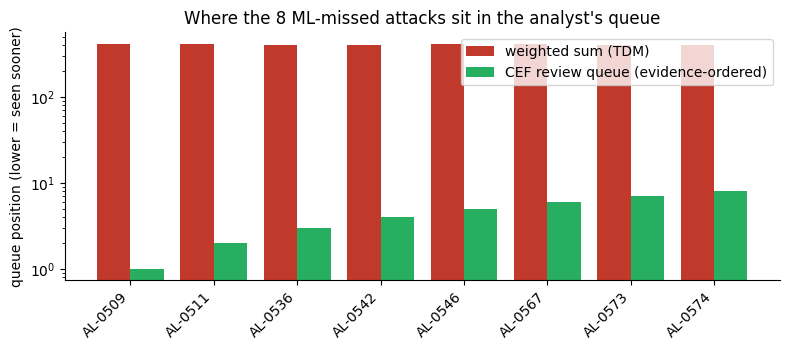

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(cmp))
ax.bar(x - 0.2, cmp.rank_weighted, 0.4, label="weighted sum (TDM)", color="#c0392b")
ax.bar(x + 0.2, [cef_pos.get(i, np.nan) for i in cmp.id], 0.4,
       label="CEF review queue (evidence-ordered)", color="#27ae60")
ax.set_xticks(x); ax.set_xticklabels(cmp.id, rotation=45, ha="right")
ax.set_ylabel("queue position (lower = seen sooner)")
ax.set_yscale("log")
ax.set_title("Where the 8 ML-missed attacks sit in the analyst's queue")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


---
## Interaction with the guardrails

The feedback guardrails must be re-examined under CEF, because `signature_override` alerts have a
property the current guardrail config does not model: their score comes from a **precision-1.000**
rule. Analyst feedback marking one a false positive is therefore either (a) a genuine rule
regression worth escalating to the administrator, or (b) analyst error - and in neither case
should it silently decay the score.

In [8]:
GUARDRAILS = {"max_feedback_reduction": 30, "critical_alert_floor": 70,
              "critical_alert_threshold": 80}

def apply_feedback(score, evidence, delta):
    reasons = []
    d = max(delta, -GUARDRAILS["max_feedback_reduction"])
    if d != delta:
        reasons.append(f"capped at -{GUARDRAILS['max_feedback_reduction']}")
    new = score + d
    if score >= GUARDRAILS["critical_alert_threshold"] and new < GUARDRAILS["critical_alert_floor"]:
        new = GUARDRAILS["critical_alert_floor"]; reasons.append("critical floor 70")
    if evidence == "signature_override":
        new = score; reasons.append("PROPOSED: signature_override is feedback-immune, routed to admin")
    return new, "; ".join(reasons) or "applied"

print("Effect of a -40 false-positive on one alert of each evidence class:\n")
for ev in ["corroborated", "signature_override", "ml_only", "none"]:
    sub = df[df.evidence == ev]
    if sub.empty:
        print(f"   {ev:<20} (no instances in this dataset)"); continue
    row = sub.sort_values("score_cef", ascending=False).iloc[0]
    new, why = apply_feedback(row.score_cef, ev, -40)
    print(f"   {ev:<20} {row.score_cef:5.1f} -> {new:5.1f}   [{why}]")


Effect of a -40 false-positive on one alert of each evidence class:

   corroborated         (no instances in this dataset)
   signature_override    60.0 ->  60.0   [capped at -30; PROPOSED: signature_override is feedback-immune, routed to admin]
   ml_only              100.0 ->  70.0   [capped at -30; critical floor 70]
   none                  49.3 ->  19.3   [capped at -30]


---
## Implementation specification

This is the contract the build plan's fusion step implements. It replaces the TDM's
`Combined = (Sig_Severity x W_sig + ML_Prob x W_ml) x 100` **and the deviation must be recorded in
`docs/deviations.md`**, since it contradicts an approved document.

```
INPUT   signature_matches[], ml_prediction, guardrail_config
OUTPUT  combined_score 0-100, evidence_class, requires_review, explanation

evidence_class =
    corroborated        if signature_hit and ml_malicious
    signature_override  if signature_hit and not ml_malicious
    ml_only             if ml_malicious and not signature_hit
    none                otherwise

combined_score =
    corroborated        min(100, max(sig_severity, ml_prob) * 100 + AGREEMENT_BONUS)
    signature_override  sig_severity * 100
    ml_only / none      ml_prob * 100

requires_review =
    True                always, for signature_override
    True                for corroborated / ml_only when score >= CRITICAL_THRESHOLD
    False               otherwise

QUEUE ORDER  (this is part of the contract, not a UI detail)
    ORDER BY evidence_priority ASC, combined_score DESC
    evidence_priority = {corroborated:0, signature_override:1, ml_only:2, none:3}

INVARIANTS
  I1  a signature hit can never lower an alert's score below sig_severity * 100
  I2  signature_override alerts are always review-flagged, whatever the score
  I3  feedback cannot decay a signature_override alert; it routes to the administrator
  I4  scoring is a pure function of its inputs (NFR-05 determinism)
  I5  no signature_override alert may rank below any ml_only alert
```

**Why the ordering is part of the contract.** The first version of this design flagged
`signature_override` alerts for review and then sorted the review queue by score - and it ranked
them *worse* than the weighted sum did (#414 of 417). Scores from different evidence classes are
not commensurable; comparing them numerically is the original error in a new costume. The queue
must order by class first. Invariant **I5** exists to stop that regression recurring, and the
failure is preserved in this notebook rather than deleted, because it is the whole reason the
contract is shaped this way.

**Configurable parameters** (replacing the inert `W_sig` / `W_ml`): `AGREEMENT_BONUS` (default 5),
`CRITICAL_THRESHOLD` (default 80), plus the per-severity score mapping. These are genuinely
configurable, because unlike the weights they change behaviour on data that actually exists.

### Consequences for the plan

1. The fusion step becomes a **re-specification**, not a port - so its golden test against the
   Node output is deleted and replaced by the invariant suite above.
2. A new **rule-tuning step** precedes it, delivering the precision-1.000 SSH rule and retiring
   the five rules notebook `02` showed to be unrecoverable on the observable features.
3. The demo narrative changes: the centrepiece is no longer "two detectors agree" but
   **"the signature layer caught an attack the model confidently called benign, and the human
   decides"** - a better demonstration of human-in-the-loop value.
4. `docs/deviations.md` gains two entries: fusion formula replaced; "agreement is strongest
   evidence" claim withdrawn.